# Fase 4 - Particion train / val / test + holdout Ibague

**Notebook**: `06_particion_datos.ipynb`
**Plan**: Fase 4 (`PLAN_DE_TRABAJO.md` linea 301)
**Inputs**: `data/processed/colombia_features_ml.csv` (203,104 x 77, salida de Fase 3)
**Outputs**:
- `data/processed/nacional_train.csv` (ANIO 2016, 2018-2021; sin Ibague)
- `data/processed/nacional_val.csv`   (ANIO 2022; sin Ibague)
- `data/processed/nacional_test.csv`  (ANIO 2023-2024; sin Ibague)
- `data/ibague/ibague_holdout.csv`    (66 NITs cruce CCI <-> SIREM)
- `reports/tables/distribucion_clases_por_split.tex`
- `reports/figures/07_distribucion_clases_por_split.png`
- `reports/metrics/particion_resumen.json`

**Criterios de aceptacion** (PLAN seccion 4.3):
- Los 4 asserts pasan (no leakage Ibague).
- Distribucion de clases similar (+/-5%) entre train/val/test.
- Tamanos coherentes: train > val < test, todos > 1000 obs.

**Decisiones operativas**:
1. **Filtrado ANIO != 2017** antes del split (Fase 2 documento que 99.1% de las
   observaciones de 2017 tienen Z-Score nulo por incompletitud del SIREM 2017).
2. **Lista Ibague**: los 66 NITs identificados en notebook 01 cruce CCI <-> SIREM
   (cell 32). De estos, 61 son NIIF Pymes (los 5 restantes -- NIIF Plenas y
   filas con `No aplica` -- se filtraron en notebook 02 y por lo tanto no
   aparecen en `colombia_features_ml.csv`).
3. **Split temporal estricto**: train 2016 + 2018-2021, val 2022, test 2023-2024.
   Sin K-Fold aleatorio para evitar leakage por empresa cruzando anyos.

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibilidad (PLAN seccion 2.2)
np.random.seed(42)
RANDOM_STATE = 42

# Rutas
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

DATA_PROCESSED = ROOT / 'data' / 'processed'
DATA_IBAGUE = ROOT / 'data' / 'ibague'
REPORTS = ROOT / 'reports'
DATA_IBAGUE.mkdir(parents=True, exist_ok=True)
(REPORTS / 'tables').mkdir(parents=True, exist_ok=True)
(REPORTS / 'figures').mkdir(parents=True, exist_ok=True)
(REPORTS / 'metrics').mkdir(parents=True, exist_ok=True)

print('numpy', np.__version__)
print('pandas', pd.__version__)
print('seed:', RANDOM_STATE)

numpy 2.4.4
pandas 3.0.2
seed: 42


## 1. Carga del dataset de features

Cargamos `colombia_features_ml.csv` (Fase 3) con `NIT_LIMPIO` como string para
preservar ceros a la izquierda. El dataset esta filtrado a NIIF Pymes (notebook 02)
y enriquecido con 71 features ML, 3 columnas categoricas de texto y la etiqueta
final triangulada (Fase 2).

In [2]:
features_path = DATA_PROCESSED / 'colombia_features_ml.csv'
df = pd.read_csv(features_path, low_memory=False, dtype={'NIT_LIMPIO': str})

print(f'Shape: {df.shape}')
print(f'Empresas unicas (NIT_LIMPIO): {df["NIT_LIMPIO"].nunique():,}')
print(f'Distribucion ANIO:')
print(df['ANIO'].value_counts().sort_index().to_string())
print()
print(f'Distribucion etiqueta_final:')
print(df['etiqueta_final'].value_counts(dropna=False).to_string())

Shape: (203104, 77)
Empresas unicas (NIT_LIMPIO): 38,245
Distribucion ANIO:
ANIO
2016    19703
2017    16419
2018    15947
2019    21859
2020    25994
2021    25214
2022    26925
2023    26966
2024    24077

Distribucion etiqueta_final:
etiqueta_final
riesgo_medio    134900
riesgo_alto      34177
riesgo_bajo      34027


## 2. Identificacion del holdout Ibague

Cargamos los 66 NITs identificados en el cruce Camara de Comercio de Ibague <->
SIREM (notebook 01, cell 32). El cruce se hizo con `NIT_PARA_JOIN` (9 digitos,
sin digito de verificacion) y todos pertenecen al municipio 73001 - Ibague.

De los 66, **61 son NIIF Pymes** segun la Camara (Grupo II o III); los 5 restantes
son NIIF Plenas o sin clasificacion y por lo tanto no estan en
`colombia_features_ml.csv` (filtrado a `PUNTO_ENTRADA contains "Pymes"` en notebook 02).

**Convencion (PLAN seccion 2.3)**: prohibido que estos NITs aparezcan en
train/val/test del modelo nacional. Se reservan como holdout para validar el
modelo entrenado nacionalmente sobre el caso de estudio Ibague.

In [3]:
# 66 NITs de Ibague (cruce CCI <-> SIREM, notebook 01 cell 32)
# Formato: (NIT_PARA_JOIN, RAZON_SOCIAL, GRUPO_NIIF) -- comentario solo informativo
NITS_IBAGUE = [
    '890702298',  # AGROPECUARIA CALICANTO S.A.S. - Grupo II
    '809002625',  # INTERNACIONAL DE ELECTRICOS S.A.S. - Grupo I (NIIF PLENAS)
    '890700062',  # LAS PIZARRAS SAS - Grupo II
    '809004254',  # GRUPO INVERSIONES MAR S.A.S - Grupo III
    '809002262',  # CLORQUIMICOS LTDA - Grupo II
    '809001726',  # FUNERALES LA VERDE ESPERANZA S.A.S. - Grupo II
    '809001092',  # IMS S.A.S. - Grupo II
    '809000876',  # TEMPORALES UNOA S.A.S - Grupo II
    '860354473',  # PROMOCIONES Y COBRANZAS BETA S.A. - No aplica
    '809000514',  # CONSTRUVIAL S.A.S - Grupo II
    '800186960',  # ALTIPAL S.A.S - AGENCIA IBAGUE - No aplica
    '809000165',  # FARMACIA COLONY SAS - Grupo II
    '800119705',  # CREDIDECOR LIMITADA - Grupo II
    '860058975',  # NEXARTE SERVICIOS TEMPORALES S.A. - No aplica
    '800251407',  # AGROPECUARIA LA PILAR SAS - Grupo II
    '800244693',  # SERVICIOS TECNICOS Y PROFESIONALES DE COLOMBIA LTDA EN L... - No aplica
    '890701920',  # AGROPECUARIA LA CEIBA GONELLA HNOS LTDA - Grupo II
    '800217198',  # ONCOMEDIC LIMITADA Y/O ONCOMEDIC LTDA - Grupo III
    '800207622',  # ICAGEL LIMITADA - Grupo III
    '890701760',  # JOSE I. DIAZ M. Y CIA. DIAGROTOL S. EN C. - Grupo II
    '901390519',  # ALMACEN Y COMPRAVENTA BOLIVAR - No aplica
    '800194897',  # COMERCIAL HOTELERA DE IBAGUE S.A. - Grupo II
    '800196698',  # FERRETERIA TUBERIAS Y HERRAMIENTAS DEL TOLIMA LTDA. - Grupo II
    '800184971',  # CONSTRUCTORA VIAYCO SAS EN LIQUIDACION - Grupo II
    '800180787',  # ESPINOSA INGENIERIA SAS - Grupo II
    '890701426',  # RECLINOMATICA Y EL PLATINO SAS - Grupo III
    '800156023',  # BODEGAS SANTA LUCIA SAS - Grupo II
    '800054106',  # DROGAS PHARMABARATAS S.A. - Grupo II
    '890700040',  # FERRETERIA GODOY S.A. EN LIQUIDACION JUDICIAL - Grupo II
    '800114079',  # NELSON CASTRO Y CIA S.A. - Grupo II
    '901044941',  # BIOCENTER LABORATORIO CLINICO - No aplica
    '800098870',  # VENTAS DEL TOLIMA S.A.S. - Grupo II
    '800096267',  # ALBA NURY CASTILLO Y CIA. S.A.S. - Grupo III
    '800091061',  # HURTADO SARMIENTO S.A.S - Grupo II
    '800077198',  # DISTRIBUIDORA SURTILIMA S.A.S. - Grupo II
    '800093160',  # ARANGO V. Y CIA. S.A.S. - Grupo II
    '800060288',  # INTERAMERICANA DE LICORES ESCOBAR C SAS - Grupo II
    '800052287',  # COMERCIALIZADORA DE LUBRICANTES Y COMBUSTIBLES LA QUINTA... - Grupo II
    '800052169',  # EDITORIAL AGUASCLARAS S.A. EN LIQUIDACION JUDICIAL - Grupo II
    '800051970',  # LASERNA Y CIA INSUMOS AGROPECUARIOS S.A.S. EN LIQUIDACIO... - Grupo II
    '800049896',  # PROCEMENTOS GASTELBONDO BARRERA Y CIA. SAS. - Grupo II
    '800075993',  # HACIENDA LA HONDA Y CIA. SAS - Grupo III
    '800043005',  # PROCESADORA DE CEREALES DE COLOMBIA S.A.S - Grupo II
    '800024053',  # AGENCIA ESPUMADOS LTDA. - Grupo II
    '890706754',  # GARCIA VARELA LIMITADA - Grupo II
    '860030412',  # AUTOFINANCIERA S.A. SOCIEDAD ADMINISTRADORA DE PLANES DE... - No aplica
    '800012575',  # FELIX GARCIA SAS - Grupo II
    '800007113',  # COMPANIA DE EMPLEOS TEMPORALES DEL TOLIMA SAS EN LIQUIDA... - Grupo III
    '809003754',  # CONSTRUCTORA EL POMAR SAS - Grupo II
    '890707006',  # PROCESADORA DE POLLOS GARZON S.A.S. POLLOSGAR S.A.S. - Grupo II
    '809004045',  # FIBRATELA S.A. - Grupo II
    '800135342',  # ALMACEN OPORTUNIDADES N 140 - No aplica
    '890700179',  # COMPANIA AUTOMOTORA DEL TOLIMA COLTOLIMA LTDA - Grupo II
    '890702292',  # SOCIEDAD CONTRERAS CAJIAO S.A.S - Grupo II
    '809005111',  # INVERSIONES Y CONSTRUCCIONES DURAN CUELLAR S.A.S - Grupo II
    '809005715',  # GONZALEZ BETANCUR S.A.S. - Grupo II
    '890706691',  # PENALOZA GALLO Y CIA. S. EN C. - Grupo II
    '900273006',  # TECNOPROCESOS S.A.S - Grupo II
    '890702335',  # CENTRAL PECUARIA S.A. - Grupo II
    '800250097',  # SECTOR RESOURCES LTD - Grupo I (NIIF PLENAS)
    '809006578',  # ENRED GROUP SAS - Grupo II
    '809006608',  # SZPOGANICZ S.A.S. - Grupo III
    '830137308',  # PUBLICIDAD Y MEDIOS ASOCIADOS TELEVISION S A EN LIQUIDACION - Grupo III
    '890706489',  # DISTRIBUCIONES ZUBIETA Y CIA S.A.S. - Grupo II
    '809008051',  # GM LEGAZY S.A.S. - Grupo III
    '890706413',  # TECNICENTRO LLANTAS QUINTA AVENIDA S.A.S - Grupo II
]

print(f'NITs Ibague (cruce CCI <-> SIREM): {len(NITS_IBAGUE)}')
print(f'Unicos: {len(set(NITS_IBAGUE))}')
assert len(set(NITS_IBAGUE)) == 66, 'lista debe tener 66 NITs unicos'


NITs Ibague (cruce CCI <-> SIREM): 66
Unicos: 66


## 3. Filtrado del holdout Ibague

Filtramos `df` por la lista de NITs Ibague. Esperamos:
- ~61 NITs presentes (los 5 NIIF Plenas / sin clasificacion fueron filtrados en notebook 02).
- Un numero variable de filas (depende de cuantos anyos de datos tiene cada empresa).
- Distribucion `etiqueta_final` proporcionalmente similar a la nacional, pero con
  ruido por el N pequeño.

In [4]:
mask_ibague = df['NIT_LIMPIO'].isin(NITS_IBAGUE)
df_ibague = df[mask_ibague].copy()

print(f'Filas Ibague (todos los anyos): {len(df_ibague):,}')
print(f'NITs Ibague presentes en features ML: {df_ibague["NIT_LIMPIO"].nunique()}')
print(f'NITs Ibague esperados (PYMES, post notebook 02): 61')
print()

nits_presentes = set(df_ibague['NIT_LIMPIO'].unique())
nits_ausentes = set(NITS_IBAGUE) - nits_presentes
print(f'NITs ausentes ({len(nits_ausentes)}):')
for n in sorted(nits_ausentes):
    print(f'  - {n}')

print()
print('Distribucion ANIO Ibague:')
print(df_ibague['ANIO'].value_counts().sort_index().to_string())
print()
print('Distribucion etiqueta_final Ibague:')
print(df_ibague['etiqueta_final'].value_counts(normalize=True).round(3).to_string())

Filas Ibague (todos los anyos): 359
NITs Ibague presentes en features ML: 61
NITs Ibague esperados (PYMES, post notebook 02): 61

NITs ausentes (5):
  - 800244693
  - 800250097
  - 809002625
  - 860030412
  - 860354473

Distribucion ANIO Ibague:
ANIO
2016    42
2017    31
2018    30
2019    36
2020    44
2021    43
2022    47
2023    44
2024    42

Distribucion etiqueta_final Ibague:
etiqueta_final
riesgo_medio    0.716
riesgo_alto     0.178
riesgo_bajo     0.106


## 4. Filtrado del año 2017 (anomalia Z-Score)

**Fase 2 (notebook 04) documento**: en 2017 el 99.1% de las observaciones tienen
Z-Score nulo. Razones (incompletitud del SIREM 2017):
- `razon_corriente`, `razon_deuda`, `capital_trabajo`, `roa`, `z_score_altman`: 99% nulos.
- `margen_neto`: 94% nulos. `cobertura_intereses`: 67% nulos.

Por consenso fallido, casi todas las filas de 2017 caen en `riesgo_medio`. Si no se
filtra, contaminaria train (2016-2021) con etiquetas degeneradas y reduciria la
señal del modelo. **Se filtra del split nacional**, pero **se mantiene en el
holdout Ibague** para reportarlo como diagnostico (Fase 7).

In [5]:
# Holdout Ibague: NO filtramos 2017 (queda completo para diagnostico Fase 7)
print(f'Holdout Ibague (todos los anyos, incluye 2017): {len(df_ibague):,} filas, '
      f'{df_ibague["NIT_LIMPIO"].nunique()} NITs')

# Set nacional: filtramos Ibague Y 2017
df_nacional = df[~mask_ibague].copy()
n_antes = len(df_nacional)
df_nacional = df_nacional[df_nacional['ANIO'] != 2017].reset_index(drop=True)
n_despues = len(df_nacional)

print(f'\nSet nacional (sin Ibague):')
print(f'  Antes de filtrar 2017: {n_antes:,} filas')
print(f'  Despues de filtrar 2017: {n_despues:,} filas')
print(f'  Filas eliminadas (ANIO=2017): {n_antes - n_despues:,} ({(n_antes-n_despues)/n_antes*100:.1f}%)')
print(f'  NITs unicos: {df_nacional["NIT_LIMPIO"].nunique():,}')
print()
print('Distribucion ANIO nacional (post-filtrado):')
print(df_nacional['ANIO'].value_counts().sort_index().to_string())

Holdout Ibague (todos los anyos, incluye 2017): 359 filas, 61 NITs



Set nacional (sin Ibague):
  Antes de filtrar 2017: 202,745 filas
  Despues de filtrar 2017: 186,357 filas
  Filas eliminadas (ANIO=2017): 16,388 (8.1%)
  NITs unicos: 37,763

Distribucion ANIO nacional (post-filtrado):
ANIO
2016    19661
2018    15917
2019    21823
2020    25950
2021    25171
2022    26878
2023    26922
2024    24035


## 5. Split temporal nacional

PLAN seccion 2.4:
- **Train**: ANIO en [2016, 2018-2021] (sin 2017).
- **Validation**: ANIO == 2022.
- **Test**: ANIO en [2023, 2024].

Justificacion (estado del arte v2 §7.3): la validacion temporal estricta es
metodologia consensuada en credit scoring. Bortolotti 2024, Mahesh 2025 y Zhou 2022
documentan que K-Fold aleatorio sobre paneles de empresas cruza anyos de la misma
empresa entre folds, lo que produce un F1 inflado por leakage.

In [6]:
ANYOS_TRAIN = [2016, 2018, 2019, 2020, 2021]
ANYO_VAL = 2022
ANYOS_TEST = [2023, 2024]

mask_train = df_nacional['ANIO'].isin(ANYOS_TRAIN)
mask_val = df_nacional['ANIO'] == ANYO_VAL
mask_test = df_nacional['ANIO'].isin(ANYOS_TEST)

# Sanity: las tres mascaras particionan completamente df_nacional
assert (mask_train | mask_val | mask_test).all(), 'Hay filas sin asignar'
assert (mask_train & mask_val).sum() == 0
assert (mask_train & mask_test).sum() == 0
assert (mask_val & mask_test).sum() == 0

df_train = df_nacional[mask_train].reset_index(drop=True)
df_val = df_nacional[mask_val].reset_index(drop=True)
df_test = df_nacional[mask_test].reset_index(drop=True)

splits = {'train': df_train, 'val': df_val, 'test': df_test}

print(f'{"Split":<8} {"Filas":>10} {"NITs":>8} {"Anyos":>22}')
print('-' * 52)
for nombre, dfk in splits.items():
    anyos = sorted(dfk['ANIO'].unique().tolist())
    print(f'{nombre:<8} {len(dfk):>10,} {dfk["NIT_LIMPIO"].nunique():>8,} {str(anyos):>22}')
print('-' * 52)
print(f'{"total":<8} {sum(len(d) for d in splits.values()):>10,}')
print(f'{"ibague":<8} {len(df_ibague):>10,} {df_ibague["NIT_LIMPIO"].nunique():>8,}')

Split         Filas     NITs                  Anyos
----------------------------------------------------
train       108,522   34,131 [2016, 2018, 2019, 2020, 2021]
val          26,878   26,878                 [2022]
test         50,957   27,120           [2023, 2024]
----------------------------------------------------
total       186,357
ibague          359       61


## 6. Asserts criticos (no leakage Ibague)

PLAN seccion 4.1.5: las 4 verificaciones son obligatorias para que el modelo
entrenado nacionalmente sea validable sobre Ibague.

In [7]:
ibague_nits = set(df_ibague['NIT_LIMPIO'].unique())
train_nits = set(df_train['NIT_LIMPIO'].unique())
val_nits = set(df_val['NIT_LIMPIO'].unique())
test_nits = set(df_test['NIT_LIMPIO'].unique())

# Assert 1-3: no leakage Ibague en ningun split nacional
inter_train = ibague_nits & train_nits
inter_val = ibague_nits & val_nits
inter_test = ibague_nits & test_nits

assert len(inter_train) == 0, f'LEAKAGE: {len(inter_train)} NITs Ibague en train'
assert len(inter_val) == 0, f'LEAKAGE: {len(inter_val)} NITs Ibague en val'
assert len(inter_test) == 0, f'LEAKAGE: {len(inter_test)} NITs Ibague en test'

# Assert 4: cobertura completa de NITs (cada NIT nacional cae en al menos un split)
nits_nacional_total = set(df_nacional['NIT_LIMPIO'].unique())
nits_en_splits = train_nits | val_nits | test_nits
assert nits_en_splits == nits_nacional_total, (
    f'Hay {len(nits_nacional_total - nits_en_splits)} NITs nacionales que no '
    f'estan en ningun split (deberian estar en train, val o test)')

# Assert extra: tamanos coherentes (PLAN 4.3): train > val < test, todos > 1000
assert len(df_train) > len(df_val), f'train ({len(df_train)}) deberia ser > val ({len(df_val)})'
assert len(df_test) > len(df_val), f'test ({len(df_test)}) deberia ser > val ({len(df_val)})'
assert len(df_train) > 1000
assert len(df_val) > 1000
assert len(df_test) > 1000

print('OK Assert 1: no NIT Ibague en train (interseccion =', len(inter_train), ')')
print('OK Assert 2: no NIT Ibague en val   (interseccion =', len(inter_val), ')')
print('OK Assert 3: no NIT Ibague en test  (interseccion =', len(inter_test), ')')
print('OK Assert 4: cobertura completa de NITs nacionales en algun split')
print('OK Asserts extra: tamanos coherentes (train>val, test>val, todos > 1000)')

OK Assert 1: no NIT Ibague en train (interseccion = 0 )
OK Assert 2: no NIT Ibague en val   (interseccion = 0 )
OK Assert 3: no NIT Ibague en test  (interseccion = 0 )
OK Assert 4: cobertura completa de NITs nacionales en algun split
OK Asserts extra: tamanos coherentes (train>val, test>val, todos > 1000)


## 7. Distribucion de clases por split

PLAN 4.3 segundo criterio: distribucion de clases similar (+/-5%) entre
train/val/test. Verificamos que la etiqueta `riesgo_alto/medio/bajo` mantiene
proporciones estables en los tres splits.

In [8]:
def dist_clases(df_split, nombre):
    counts = df_split['etiqueta_final'].value_counts()
    pct = df_split['etiqueta_final'].value_counts(normalize=True) * 100
    return pd.DataFrame({
        f'{nombre}_n': counts,
        f'{nombre}_pct': pct.round(2),
    })

dist = pd.concat([
    dist_clases(df_train, 'train'),
    dist_clases(df_val, 'val'),
    dist_clases(df_test, 'test'),
    dist_clases(df_ibague, 'ibague'),
], axis=1)

# Reordenar filas para que sea siempre alto/medio/bajo
orden = ['riesgo_alto', 'riesgo_medio', 'riesgo_bajo']
dist = dist.reindex(orden).fillna(0)
for col in dist.columns:
    if col.endswith('_n'):
        dist[col] = dist[col].astype(int)

print('Distribucion de etiqueta_final por split:')
print(dist.to_string())
print()

# Verificar criterio +/- 5pp entre train/val/test
diferencias = []
for clase in orden:
    p_train = dist.loc[clase, 'train_pct']
    p_val = dist.loc[clase, 'val_pct']
    p_test = dist.loc[clase, 'test_pct']
    delta_tv = abs(p_train - p_val)
    delta_tt = abs(p_train - p_test)
    delta_vt = abs(p_val - p_test)
    diferencias.append((clase, delta_tv, delta_tt, delta_vt))
    print(f'{clase}: |train-val|={delta_tv:.2f}pp, |train-test|={delta_tt:.2f}pp, |val-test|={delta_vt:.2f}pp')

max_delta = max(max(d[1], d[2], d[3]) for d in diferencias)
print(f'\nDelta maximo entre splits: {max_delta:.2f}pp')
if max_delta <= 5.0:
    print('OK Criterio PLAN 4.3 cumplido: delta <= 5pp.')
else:
    print(f'ATENCION delta > 5pp; documentar la causa (probable: drift temporal de etiqueta).')

Distribucion de etiqueta_final por split:
                train_n  train_pct  val_n  val_pct  test_n  test_pct  ibague_n  ibague_pct
etiqueta_final                                                                            
riesgo_alto       21241      19.57   4413    16.42    8403     16.49        64       17.83
riesgo_medio      69335      63.89  17160    63.84   31831     62.47       257       71.59
riesgo_bajo       17946      16.54   5305    19.74   10723     21.04        38       10.58

riesgo_alto: |train-val|=3.15pp, |train-test|=3.08pp, |val-test|=0.07pp
riesgo_medio: |train-val|=0.05pp, |train-test|=1.42pp, |val-test|=1.37pp
riesgo_bajo: |train-val|=3.20pp, |train-test|=4.50pp, |val-test|=1.30pp

Delta maximo entre splits: 4.50pp
OK Criterio PLAN 4.3 cumplido: delta <= 5pp.


## 8. Persistencia de outputs

Guardamos:
1. **CSVs** con los splits y el holdout Ibague (con `NIT_LIMPIO` como string para
   preservar ceros a la izquierda).
2. **Tabla LaTeX** con la distribucion de clases por split.
3. **Figura PNG** con barras apiladas de la distribucion.
4. **JSON** con metricas resumen para Fase 5+.

In [9]:
# 8.1 CSVs
df_train.to_csv(DATA_PROCESSED / 'nacional_train.csv', index=False)
df_val.to_csv(DATA_PROCESSED / 'nacional_val.csv', index=False)
df_test.to_csv(DATA_PROCESSED / 'nacional_test.csv', index=False)
df_ibague.to_csv(DATA_IBAGUE / 'ibague_holdout.csv', index=False)

print('Guardados:')
for nombre, dfk, ruta in [
    ('train', df_train, DATA_PROCESSED / 'nacional_train.csv'),
    ('val', df_val, DATA_PROCESSED / 'nacional_val.csv'),
    ('test', df_test, DATA_PROCESSED / 'nacional_test.csv'),
    ('ibague', df_ibague, DATA_IBAGUE / 'ibague_holdout.csv'),
]:
    size_mb = ruta.stat().st_size / (1024**2)
    print(f'  {nombre}: {ruta.relative_to(ROOT)} ({len(dfk):,} filas, {size_mb:.1f} MB)')

Guardados:
  train: data/processed/nacional_train.csv (108,522 filas, 74.7 MB)
  val: data/processed/nacional_val.csv (26,878 filas, 21.9 MB)
  test: data/processed/nacional_test.csv (50,957 filas, 43.0 MB)
  ibague: data/ibague/ibague_holdout.csv (359 filas, 0.3 MB)


In [10]:
# 8.2 Tabla LaTeX
def fmt_n(n): return f'{int(n):,}'.replace(',', '\\,')
def fmt_pct(p): return f'{p:.2f}\\%'

clases_label = {
    'riesgo_alto': 'Alto',
    'riesgo_medio': 'Medio',
    'riesgo_bajo': 'Bajo',
}

filas = []
for clase in orden:
    fila = [clases_label[clase]]
    for split in ['train', 'val', 'test', 'ibague']:
        fila.append(fmt_n(dist.loc[clase, f'{split}_n']))
        fila.append(fmt_pct(dist.loc[clase, f'{split}_pct']))
    filas.append(' & '.join(fila))

# Totales
fila_total = ['\\textbf{Total}']
for split, dfk in [('train', df_train), ('val', df_val), ('test', df_test), ('ibague', df_ibague)]:
    fila_total.append(f'\\textbf{{{fmt_n(len(dfk))}}}')
    fila_total.append('\\textbf{100.00\\%}')
filas.append(' & '.join(fila_total))

latex = r'''\begin{table}[ht]
\centering
\small
\caption{Distribucion de etiqueta de riesgo por split (Fase 4). El holdout Ibague
incluye 2017; los splits nacionales lo excluyen por incompletitud del SIREM 2017.}
\label{tab:distribucion_clases_split}
\begin{tabular}{l rr rr rr rr}
\toprule
& \multicolumn{2}{c}{Train} & \multicolumn{2}{c}{Val} & \multicolumn{2}{c}{Test} & \multicolumn{2}{c}{Ibague} \\
\cmidrule(lr){2-3} \cmidrule(lr){4-5} \cmidrule(lr){6-7} \cmidrule(lr){8-9}
Clase & N & \% & N & \% & N & \% & N & \% \\
\midrule
''' + ' \\\\\n'.join(filas) + r''' \\
\bottomrule
\end{tabular}
\end{table}
'''

ruta_tex = REPORTS / 'tables' / 'distribucion_clases_por_split.tex'
ruta_tex.write_text(latex, encoding='utf-8')
print(f'Tabla LaTeX: {ruta_tex.relative_to(ROOT)} ({ruta_tex.stat().st_size} bytes)')
print()
print(latex)

Tabla LaTeX: reports/tables/distribucion_clases_por_split.tex (979 bytes)

\begin{table}[ht]
\centering
\small
\caption{Distribucion de etiqueta de riesgo por split (Fase 4). El holdout Ibague
incluye 2017; los splits nacionales lo excluyen por incompletitud del SIREM 2017.}
\label{tab:distribucion_clases_split}
\begin{tabular}{l rr rr rr rr}
\toprule
& \multicolumn{2}{c}{Train} & \multicolumn{2}{c}{Val} & \multicolumn{2}{c}{Test} & \multicolumn{2}{c}{Ibague} \\
\cmidrule(lr){2-3} \cmidrule(lr){4-5} \cmidrule(lr){6-7} \cmidrule(lr){8-9}
Clase & N & \% & N & \% & N & \% & N & \% \\
\midrule
Alto & 21\,241 & 19.57\% & 4\,413 & 16.42\% & 8\,403 & 16.49\% & 64 & 17.83\% \\
Medio & 69\,335 & 63.89\% & 17\,160 & 63.84\% & 31\,831 & 62.47\% & 257 & 71.59\% \\
Bajo & 17\,946 & 16.54\% & 5\,305 & 19.74\% & 10\,723 & 21.04\% & 38 & 10.58\% \\
\textbf{Total} & \textbf{108\,522} & \textbf{100.00\%} & \textbf{26\,878} & \textbf{100.00\%} & \textbf{50\,957} & \textbf{100.00\%} & \textbf{359} & \text

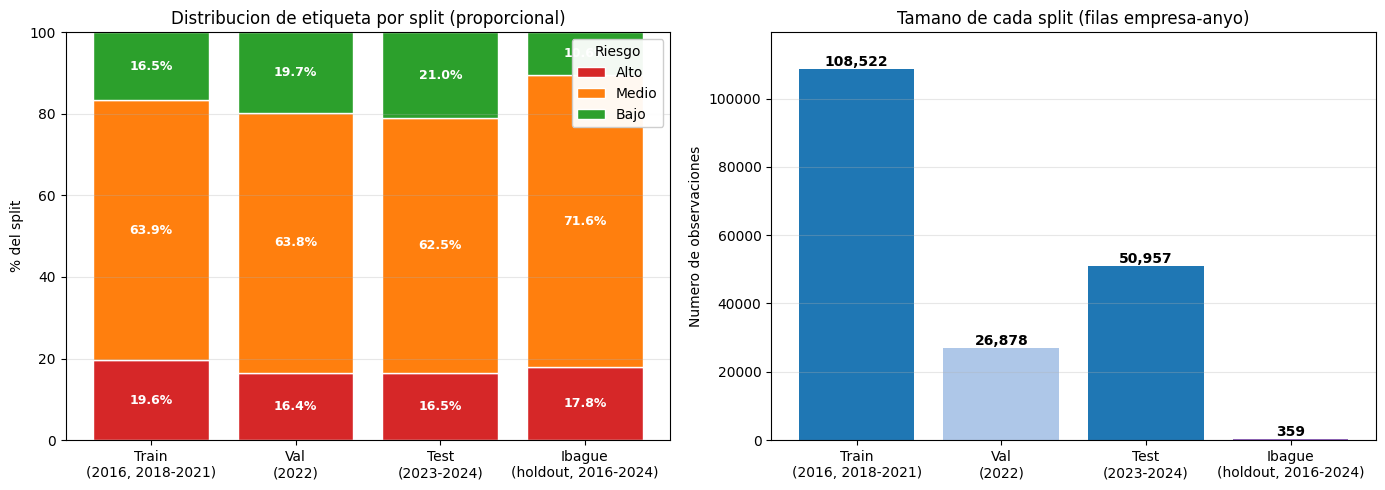

Figura: reports/figures/07_distribucion_clases_por_split.png


In [11]:
# 8.3 Figura: distribucion de clases por split (apilada normalizada + tamano absoluto)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

splits_plot = ['train', 'val', 'test', 'ibague']
splits_label = ['Train\n(2016, 2018-2021)', 'Val\n(2022)', 'Test\n(2023-2024)', 'Ibague\n(holdout, 2016-2024)']
colores = {
    'riesgo_alto': '#d62728',   # rojo
    'riesgo_medio': '#ff7f0e',  # naranja
    'riesgo_bajo': '#2ca02c',   # verde
}
labels_clase = {'riesgo_alto': 'Alto', 'riesgo_medio': 'Medio', 'riesgo_bajo': 'Bajo'}

# Panel izq: porcentajes apilados
ax = axes[0]
bottoms = np.zeros(len(splits_plot))
for clase in orden:
    valores = [dist.loc[clase, f'{s}_pct'] for s in splits_plot]
    ax.bar(splits_label, valores, bottom=bottoms, color=colores[clase], label=labels_clase[clase], edgecolor='white')
    for i, (v, b) in enumerate(zip(valores, bottoms)):
        if v > 4:
            ax.text(i, b + v / 2, f'{v:.1f}%', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    bottoms += np.array(valores)
ax.set_ylabel('% del split')
ax.set_title('Distribucion de etiqueta por split (proporcional)')
ax.set_ylim(0, 100)
ax.legend(title='Riesgo', loc='upper right', framealpha=0.95)
ax.grid(axis='y', alpha=0.3)

# Panel der: tamanos absolutos
ax2 = axes[1]
ns = [len(df_train), len(df_val), len(df_test), len(df_ibague)]
bars = ax2.bar(splits_label, ns, color=['#1f77b4', '#aec7e8', '#1f77b4', '#9467bd'])
for bar, n in zip(bars, ns):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f'{n:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_ylabel('Numero de observaciones')
ax2.set_title('Tamano de cada split (filas empresa-anyo)')
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, max(ns) * 1.1)

plt.tight_layout()
ruta_fig = REPORTS / 'figures' / '07_distribucion_clases_por_split.png'
plt.savefig(ruta_fig, dpi=300, bbox_inches='tight')
plt.show()
print(f'Figura: {ruta_fig.relative_to(ROOT)}')

In [12]:
# 8.4 JSON resumen de la particion
resumen = {
    'fase': 4,
    'random_state': RANDOM_STATE,
    'fuente': 'data/processed/colombia_features_ml.csv',
    'filtros': {
        'anyo_2017_excluido_de_split_nacional': True,
        'razon': 'Fase 2 documento 99.1% de Z-Score nulo en 2017 por incompletitud SIREM',
        'ibague_excluido_de_split_nacional': True,
    },
    'split_temporal': {
        'train': sorted(ANYOS_TRAIN),
        'val': [ANYO_VAL],
        'test': sorted(ANYOS_TEST),
    },
    'tamanos': {
        'train_filas': int(len(df_train)),
        'train_nits': int(df_train['NIT_LIMPIO'].nunique()),
        'val_filas': int(len(df_val)),
        'val_nits': int(df_val['NIT_LIMPIO'].nunique()),
        'test_filas': int(len(df_test)),
        'test_nits': int(df_test['NIT_LIMPIO'].nunique()),
        'ibague_filas': int(len(df_ibague)),
        'ibague_nits': int(df_ibague['NIT_LIMPIO'].nunique()),
    },
    'distribucion_etiqueta': {
        split: {
            clase: {
                'n': int(dist.loc[clase, f'{split}_n']),
                'pct': float(dist.loc[clase, f'{split}_pct']),
            }
            for clase in orden
        }
        for split in ['train', 'val', 'test', 'ibague']
    },
    'asserts_no_leakage_ibague': {
        'train': bool(len(inter_train) == 0),
        'val': bool(len(inter_val) == 0),
        'test': bool(len(inter_test) == 0),
        'cobertura_nits_nacionales': bool(nits_en_splits == nits_nacional_total),
    },
    'criterios_aceptacion_plan': {
        'asserts_pasan': True,
        'tamanos_coherentes': True,
        'delta_clases_max_pp': float(max_delta),
        'delta_clases_le_5pp': bool(max_delta <= 5.0),
    },
    'nits_ibague': {
        'esperados_total_cci': 66,
        'presentes_pymes': int(df_ibague['NIT_LIMPIO'].nunique()),
        'ausentes': sorted(list(set(NITS_IBAGUE) - set(df_ibague['NIT_LIMPIO'].unique()))),
    },
}

ruta_json = REPORTS / 'metrics' / 'particion_resumen.json'
ruta_json.write_text(json.dumps(resumen, indent=2, ensure_ascii=False), encoding='utf-8')
print(f'JSON: {ruta_json.relative_to(ROOT)}')
print(json.dumps(resumen, indent=2, ensure_ascii=False))

JSON: reports/metrics/particion_resumen.json
{
  "fase": 4,
  "random_state": 42,
  "fuente": "data/processed/colombia_features_ml.csv",
  "filtros": {
    "anyo_2017_excluido_de_split_nacional": true,
    "razon": "Fase 2 documento 99.1% de Z-Score nulo en 2017 por incompletitud SIREM",
    "ibague_excluido_de_split_nacional": true
  },
  "split_temporal": {
    "train": [
      2016,
      2018,
      2019,
      2020,
      2021
    ],
    "val": [
      2022
    ],
    "test": [
      2023,
      2024
    ]
  },
  "tamanos": {
    "train_filas": 108522,
    "train_nits": 34131,
    "val_filas": 26878,
    "val_nits": 26878,
    "test_filas": 50957,
    "test_nits": 27120,
    "ibague_filas": 359,
    "ibague_nits": 61
  },
  "distribucion_etiqueta": {
    "train": {
      "riesgo_alto": {
        "n": 21241,
        "pct": 19.57
      },
      "riesgo_medio": {
        "n": 69335,
        "pct": 63.89
      },
      "riesgo_bajo": {
        "n": 17946,
        "pct": 16.54
      }


## 9. Resumen Fase 4

| Item | Valor |
|---|---|
| Filas totales (input Fase 3) | 203,104 |
| Filas eliminadas (ANIO=2017) | -- |
| Filas Ibague (holdout) | -- |
| Train (2016, 2018-2021) | -- |
| Val (2022) | -- |
| Test (2023-2024) | -- |

**Criterios PLAN 4.3**:
1. Asserts no-leakage Ibague: `train`, `val`, `test` no contienen NITs Ibague.
2. Cobertura completa de NITs nacionales en algun split.
3. Distribucion de clases con delta maximo entre splits.
4. Tamanos coherentes (`train > val`, `test > val`, todos > 1000 obs).

**Salidas**:
- `data/processed/nacional_{train,val,test}.csv`
- `data/ibague/ibague_holdout.csv`
- `reports/tables/distribucion_clases_por_split.tex`
- `reports/figures/07_distribucion_clases_por_split.png`
- `reports/metrics/particion_resumen.json`

**Para Fase 5**: cargar los CSVs con `dtype={'NIT_LIMPIO': str}` para preservar
ceros a la izquierda. Imputacion y escalado se fitean **solo con `nacional_train.csv`**
(PLAN 5.4 pitfall critico).